# 🏥 의료 데이터 분석
## 03. 탐색적 데이터 분석 (EDA) & 심화 패턴 분석

---

전처리된 통합 데이터셋을 활용하여 환자의 기본 특성을 파악하고, 비지도 학습을 통해 복잡한 데이터 구조를 탐색합니다.

**분석 목표:**
1. 환자 특성과 입원 패턴의 관계
2. 진단 경향성 파악
3. 검사와 입원 기간의 상관관계
4. 시계열 트렌드 분석
5. PCA, t-SNE를 활용한 다변량 패턴 분석

---
## 1. 환경 설정 및 데이터 준비

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 크기
plt.rcParams['figure.figsize'] = (14, 6)

### 데이터 로드 및 전처리

02_feature_engineering.ipynb의 코드를 재실행하여 데이터를 준비합니다.

In [41]:
# 저장된 csv 파일 로드
df_main = pd.read_csv('processed_healthcare_data.csv', encoding='utf-8-sig')

print("✅ 분석용 통합 데이터셋 로드 완료")
print(f"전체 행 개수: {len(df_main)}")
print(f"전체 컬럼 수: {df_main.shape[1]}")

# 3. 데이터 상단 확인
df_main.head()

✅ 분석용 통합 데이터셋 로드 완료
전체 행 개수: 372
전체 컬럼 수: 165


,PatientID,AdmissionID,AdmissionStartDate,AdmissionEndDate,LengthOfStay,AdmissionYear,AdmissionMonth,AdmissionDayOfWeek,AdmissionDayName,LengthOfStayCategory,...,Lab_Trend_METABOLIC: SODIUM,Lab_Trend_METABOLIC: TOTAL PROTEIN,Lab_Trend_URINALYSIS: PH,Lab_Trend_URINALYSIS: RED BLOOD CELLS,Lab_Trend_URINALYSIS: SPECIFIC GRAVITY,Lab_Trend_URINALYSIS: WHITE BLOOD CELLS,LabTestCount,LabTestVariety,Total_Abnormal_Count,Total_Lab_Variability
0,7A025E77-7832-4F53-B9A7-09A3F98AC17E,7,2011-10-12 14:55:02.027,2011-10-22 01:16:07.557,9,2011,10,2,수,중기(8-14일),...,15.7,0.4,0.1,-0.3,0.0,3.7,230,35,34.0,6.985972
1,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,1,1993-02-11 18:57:04.003,1993-02-24 17:22:29.713,12,1993,2,3,목,중기(8-14일),...,-14.1,1.3,-0.5,-1.4,0.0,1.1,355,35,49.0,8.480702
2,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,2,2002-11-28 19:06:31.117,2002-12-04 19:14:40.797,6,2002,11,3,목,단기(4-7일),...,17.6,-1.8,-1.5,-0.2,0.0,0.3,202,35,28.0,6.837585
3,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,3,2011-07-19 18:42:45.287,2011-07-25 04:57:42.053,5,2011,7,1,화,단기(4-7일),...,-1.2,0.5,1.0,2.0,0.0,-0.1,150,35,23.0,8.588358
4,886B5885-1EE2-49F3-98D5-A2F02EB8A9D4,1,1994-12-03 22:20:46.077,1994-12-20 20:24:56.010,16,1994,12,5,토,장기(15-30일),...,-12.3,-2.5,-1.4,0.5,0.0,4.1,424,35,54.0,8.029381


---
## 2. 환자 인구통계 분석

### 2.1 성별 및 연령대 분포

📊 분석 결과 - 전체 환자 평균 연령: 68.8세


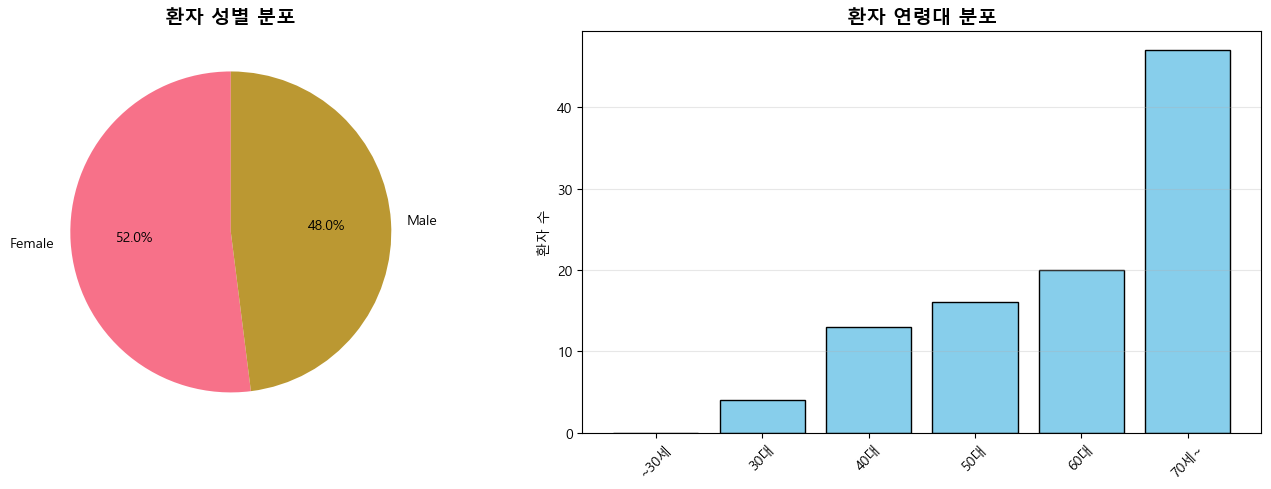

📊 성별 분포:
Female    52
Male      48
Name: PatientGender, dtype: int64

📊 연령대 분포:
~30세     0
30대      4
40대     13
50대     16
60대     20
70세~    47
Name: AgeGroup, dtype: int64
💡 인사이트: 성비는 균형적이나, 60대 이상 고령층 환자가 전체의 과반수 이상을 차지하여 고령화된 환자군 특성을 보임


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성별 분포
mean_age = df_patients['Age'].mean()
print(f"📊 분석 결과 - 전체 환자 평균 연령: {mean_age:.1f}세")

gender_counts = df_patients['PatientGender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('환자 성별 분포', fontsize=14, weight='bold')

# 연령대 분포
age_counts = df_patients['AgeGroup'].value_counts().sort_index()
axes[1].bar(range(len(age_counts)), age_counts.values, color='skyblue', edgecolor='black')
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=45)
axes[1].set_title('환자 연령대 분포', fontsize=14, weight='bold')
axes[1].set_ylabel('환자 수')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 성별 분포:")
print(gender_counts)
print("\n📊 연령대 분포:")
print(age_counts)

plt.show()
print("💡 인사이트: 성비는 균형적이나, 60대 이상 고령층 환자가 전체의 과반수 이상을 차지하여 고령화된 환자군 특성을 보임")

### 2.2 인종 및 결혼 상태

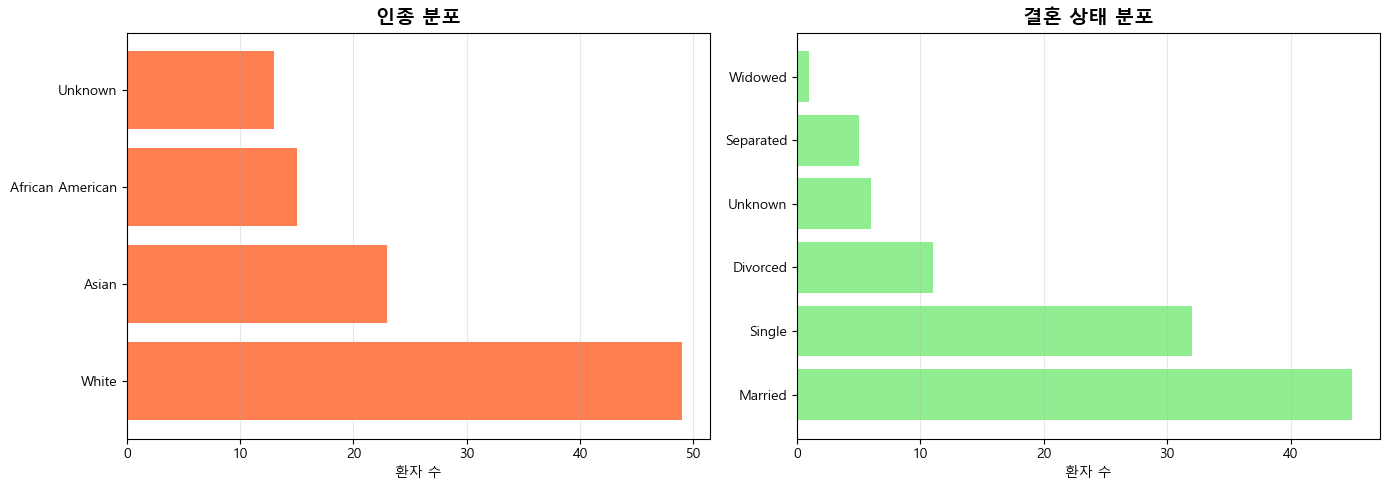

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 인종 분포
race_counts = df_patients['PatientRace'].value_counts()
axes[0].barh(range(len(race_counts)), race_counts.values, color='coral')
axes[0].set_yticks(range(len(race_counts)))
axes[0].set_yticklabels(race_counts.index)
axes[0].set_title('인종 분포', fontsize=14, weight='bold')
axes[0].set_xlabel('환자 수')
axes[0].grid(axis='x', alpha=0.3)

# 결혼 상태
marital_counts = df_patients['PatientMaritalStatus'].value_counts()
axes[1].barh(range(len(marital_counts)), marital_counts.values, color='lightgreen')
axes[1].set_yticks(range(len(marital_counts)))
axes[1].set_yticklabels(marital_counts.index)
axes[1].set_title('결혼 상태 분포', fontsize=14, weight='bold')
axes[1].set_xlabel('환자 수')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 입원 패턴 분석

### 3.1 입원 기간 분포

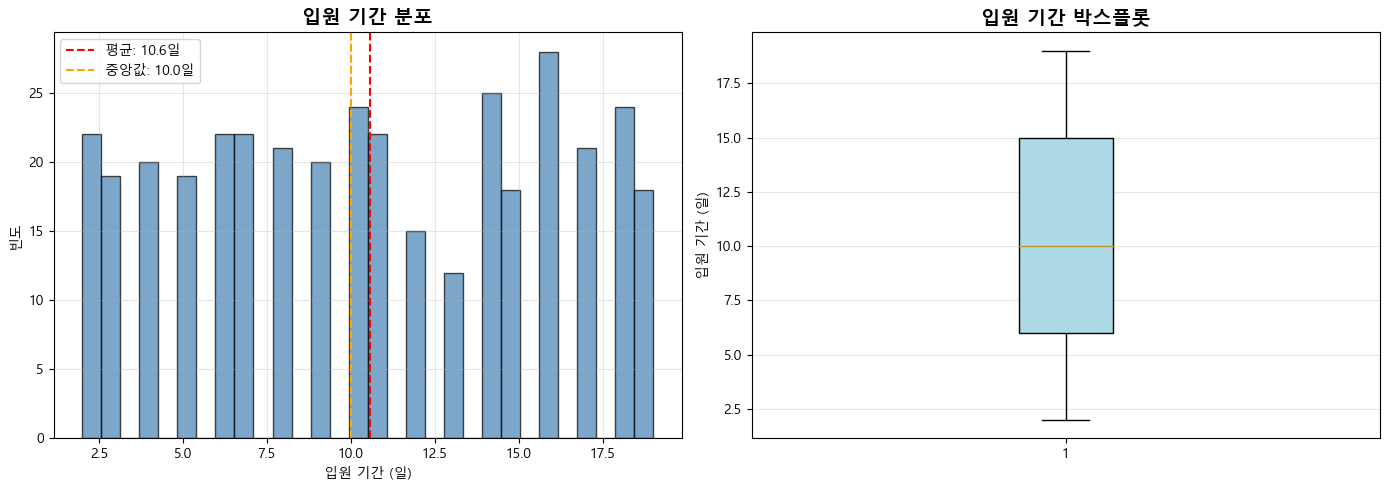

📊 입원 기간 통계:
count    372.000000
mean      10.556452
std        5.228940
min        2.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       19.000000
Name: LengthOfStay, dtype: float64
💡 인사이트: 입원 기간은 평균 10.6일이며, 대부분의 환자가 10일 내외에 밀집되어 있으나 일부 장기 입원 환자로 인해 우측 편포를 보임


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df_main['LengthOfStay'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_main['LengthOfStay'].mean(), color='red', linestyle='--', label=f'평균: {df_main["LengthOfStay"].mean():.1f}일')
axes[0].axvline(df_main['LengthOfStay'].median(), color='orange', linestyle='--', label=f'중앙값: {df_main["LengthOfStay"].median():.1f}일')
axes[0].set_title('입원 기간 분포', fontsize=14, weight='bold')
axes[0].set_xlabel('입원 기간 (일)')
axes[0].set_ylabel('빈도')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 박스플롯
axes[1].boxplot(df_main['LengthOfStay'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('입원 기간 박스플롯', fontsize=14, weight='bold')
axes[1].set_ylabel('입원 기간 (일)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 입원 기간 통계:")
print(df_main['LengthOfStay'].describe())

plt.show()
print("💡 인사이트: 입원 기간은 평균 10.6일이며, 대부분의 환자가 10일 내외에 밀집되어 있으나 일부 장기 입원 환자로 인해 우측 편포를 보임")

### 3.2 연도별 입원 추이

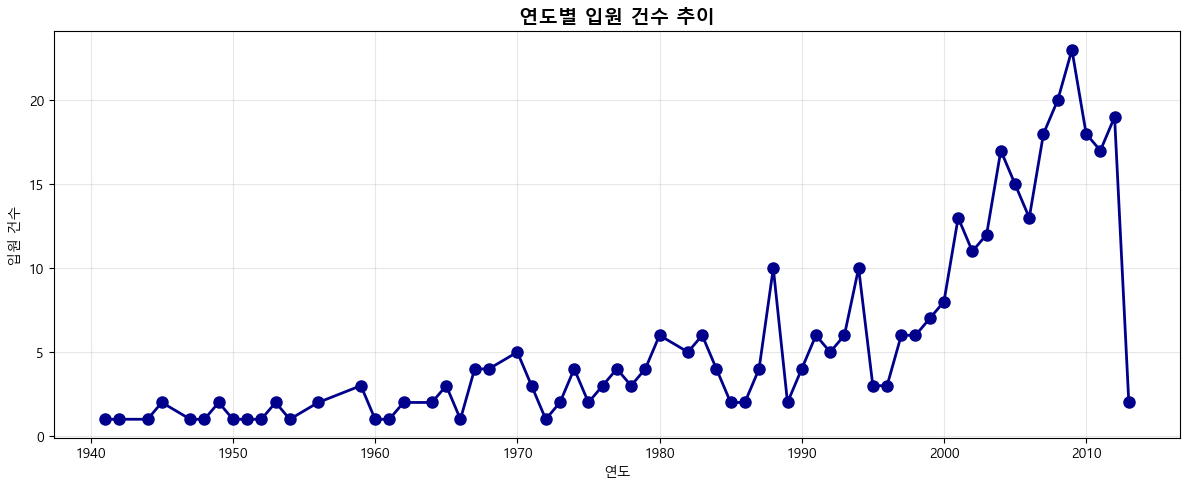

📈 연도별 입원 건수:
AdmissionYear
1941     1
1942     1
1944     1
1945     2
1947     1
        ..
2009    23
2010    18
2011    17
2012    19
2013     2
Length: 65, dtype: int64


In [45]:
yearly_admissions = df_main.groupby('AdmissionYear').size()

plt.figure(figsize=(12, 5))
plt.plot(yearly_admissions.index, yearly_admissions.values, marker='o', linewidth=2, markersize=8, color='darkblue')
plt.title('연도별 입원 건수 추이', fontsize=14, weight='bold')
plt.xlabel('연도')
plt.ylabel('입원 건수')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📈 연도별 입원 건수:")
print(yearly_admissions)

### 3.3 성별/연령대별 입원 기간 비교

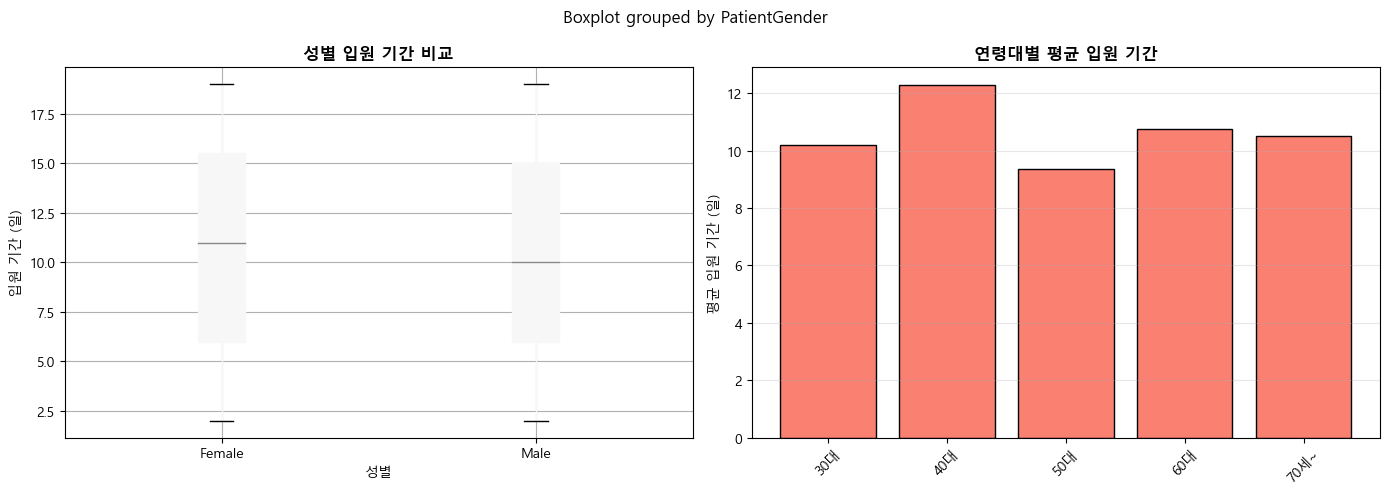

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성별
df_main.boxplot(column='LengthOfStay', by='PatientGender', ax=axes[0], patch_artist=True)
axes[0].set_title('성별 입원 기간 비교', fontsize=12, weight='bold')
axes[0].set_xlabel('성별')
axes[0].set_ylabel('입원 기간 (일)')
plt.sca(axes[0])
plt.xticks(rotation=0)

# 연령대
age_los = df_main.groupby('AgeGroup')['LengthOfStay'].mean().sort_index()
axes[1].bar(range(len(age_los)), age_los.values, color='salmon', edgecolor='black')
axes[1].set_xticks(range(len(age_los)))
axes[1].set_xticklabels(age_los.index, rotation=45)
axes[1].set_title('연령대별 평균 입원 기간', fontsize=12, weight='bold')
axes[1].set_ylabel('평균 입원 기간 (일)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. 검사 데이터 분석

### 4.1 검사 종류별 빈도

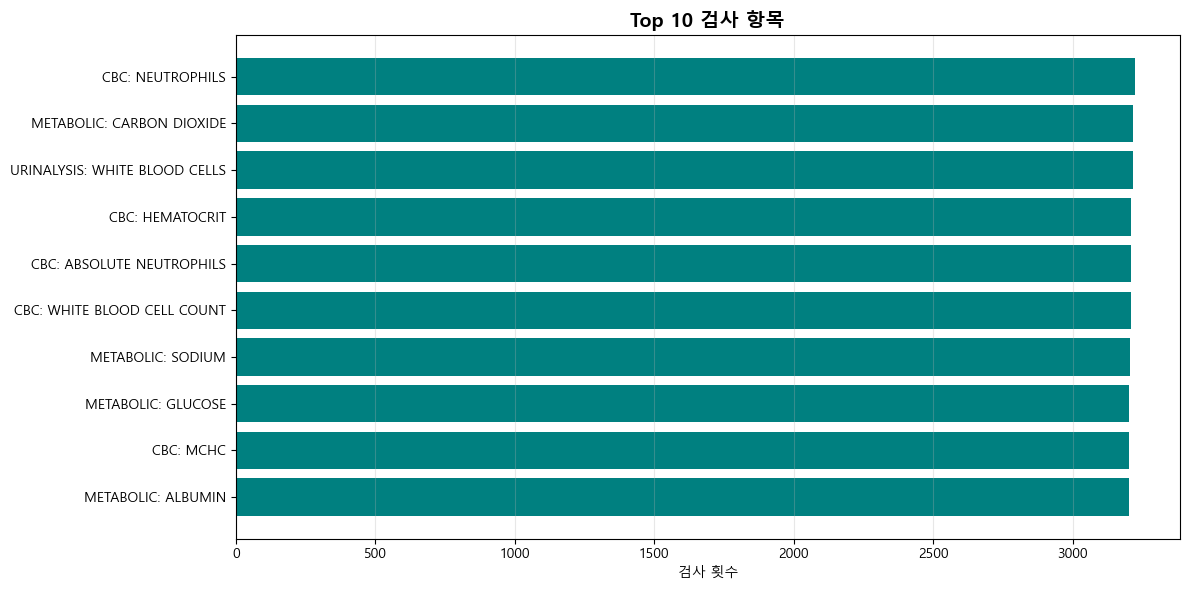

🔬 Top 10 검사 항목:
CBC: NEUTROPHILS                 3224
METABOLIC: CARBON DIOXIDE        3218
URINALYSIS: WHITE BLOOD CELLS    3218
CBC: HEMATOCRIT                  3211
CBC: ABSOLUTE NEUTROPHILS        3210
CBC: WHITE BLOOD CELL COUNT      3209
METABOLIC: SODIUM                3207
METABOLIC: GLUCOSE               3202
CBC: MCHC                        3202
METABOLIC: ALBUMIN               3202
Name: LabName, dtype: int64


In [60]:
top_labs = df_labs['LabName'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_labs)), top_labs.values, color='teal')
plt.yticks(range(len(top_labs)), top_labs.index)
plt.title('Top 10 검사 항목', fontsize=14, weight='bold')
plt.xlabel('검사 횟수')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("🔬 Top 10 검사 항목:")
print(top_labs)

### 4.2 검사 횟수와 입원 기간의 상관관계

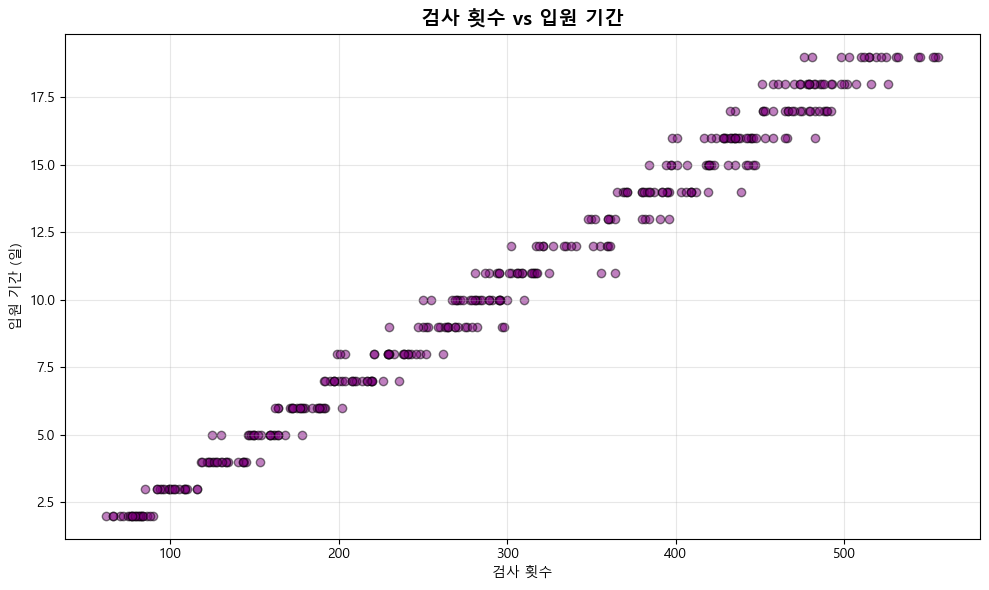


📊 상관계수: 0.993
💡 인사이트: 입원 기간과 검사 횟수 간 상관계수가 0.993로 극도로 높아, 검사 빈도가 입원 기간의 핵심 예측 인자임을 시사함


In [61]:
plt.figure(figsize=(10, 6))
plt.scatter(df_main['LabTestCount'], df_main['LengthOfStay'], alpha=0.5, c='purple', edgecolor='black')
plt.title('검사 횟수 vs 입원 기간', fontsize=14, weight='bold')
plt.xlabel('검사 횟수')
plt.ylabel('입원 기간 (일)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

correlation = df_main[['LabTestCount', 'LengthOfStay']].corr().iloc[0, 1]
print(f"\n📊 상관계수: {correlation:.3f}")


plt.show()
print(f"💡 인사이트: 입원 기간과 검사 횟수 간 상관계수가 {df_main['LengthOfStay'].corr(df_main['LabTestCount']):.3f}로 극도로 높아, 검사 빈도가 입원 기간의 핵심 예측 인자임을 시사함")

---
## 5. 진단 분석

### 5.1 빈번한 진단 Top 10

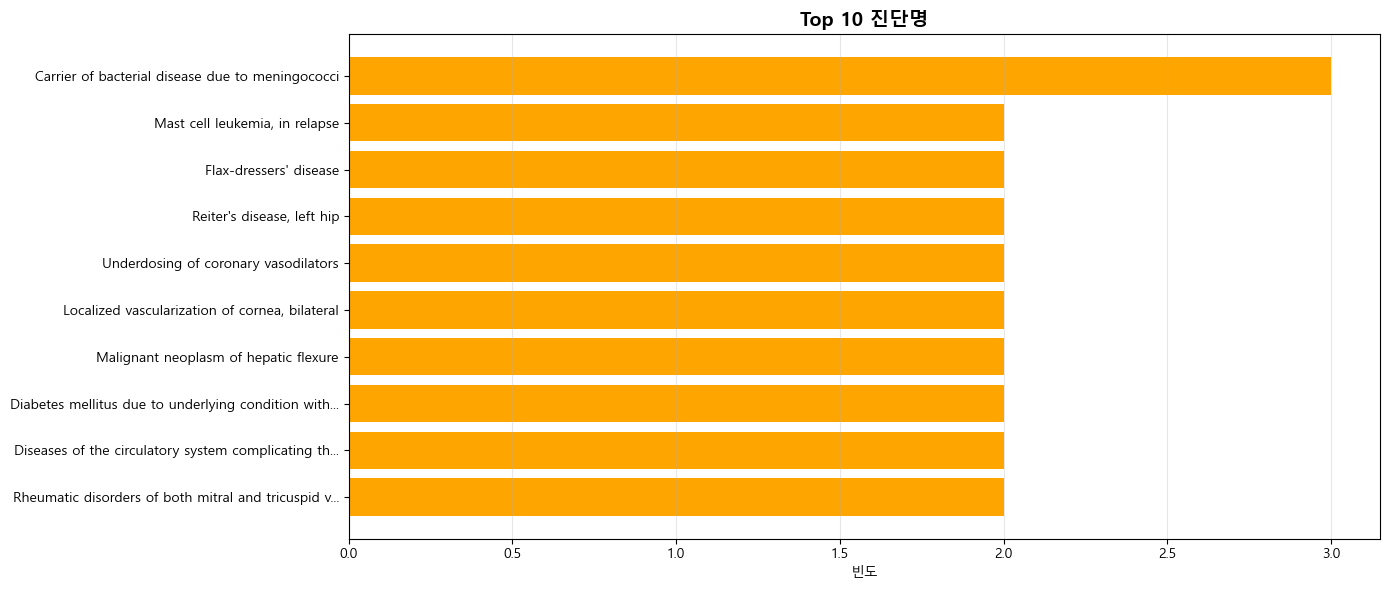

💊 Top 10 진단:
1. Carrier of bacterial disease due to meningococci - 3회
2. Mast cell leukemia, in relapse - 2회
3. Flax-dressers' disease - 2회
4. Reiter's disease, left hip - 2회
5. Underdosing of coronary vasodilators - 2회
6. Localized vascularization of cornea, bilateral - 2회
7. Malignant neoplasm of hepatic flexure - 2회
8. Diabetes mellitus due to underlying condition with mild nonp - 2회
9. Diseases of the circulatory system complicating the puerperi - 2회
10. Rheumatic disorders of both mitral and tricuspid valves - 2회


In [49]:
top_diagnoses = df_diagnoses['PrimaryDiagnosisDescription'].value_counts().head(10)

plt.figure(figsize=(14, 6))
plt.barh(range(len(top_diagnoses)), top_diagnoses.values, color='orange')
plt.yticks(range(len(top_diagnoses)), [desc[:50] + '...' if len(desc) > 50 else desc for desc in top_diagnoses.index])
plt.title('Top 10 진단명', fontsize=14, weight='bold')
plt.xlabel('빈도')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("💊 Top 10 진단:")
for i, (diag, count) in enumerate(top_diagnoses.items(), 1):
    print(f"{i}. {diag[:60]} - {count}회")

---
## 6. 다변량 패턴 분석: 차원 축소 (PCA & t-SNE)

### 6.1 PCA & t-SNE

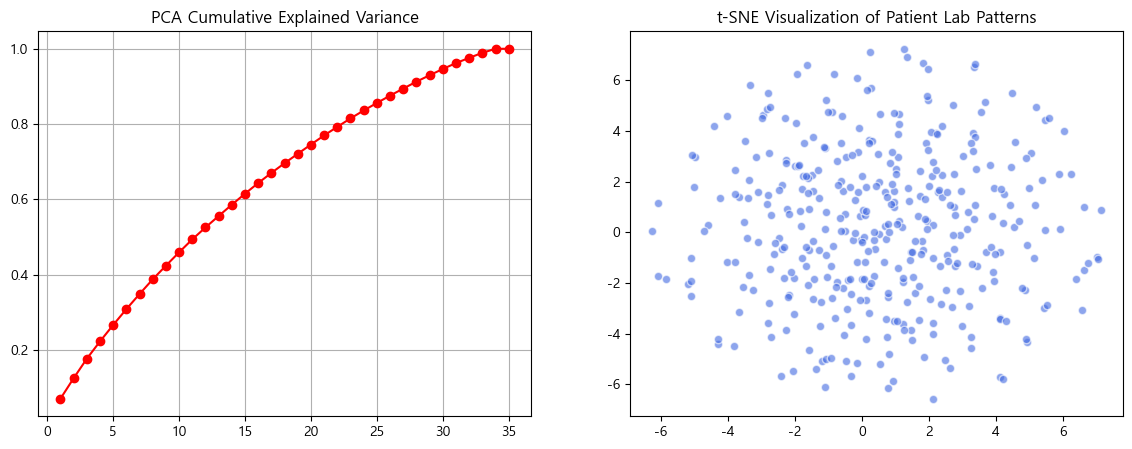

전체 변수 PC1 설명력: 0.0700


In [51]:
# 분석용 수치 피처 선택 (Lab_Mean 컬럼 활용)
lab_mean_cols = [c for c in df_main.columns if 'Lab_Mean' in c]
X_scaled = StandardScaler().fit_transform(df_main[lab_mean_cols].fillna(0))

# 1. PCA 실행
pca = PCA().fit(X_scaled)

plt.figure(figsize=(14, 5))

# PCA Scree Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)

# 2. t-SNE 실행
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_res = tsne.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
plt.scatter(tsne_res[:, 0], tsne_res[:, 1], alpha=0.6, c='royalblue', edgecolors='w')
plt.title('t-SNE Visualization of Patient Lab Patterns')
plt.show()

print(f"전체 변수 PC1 설명력: {pca.explained_variance_ratio_[0]:.4f}")

### 6.4 군집 분석

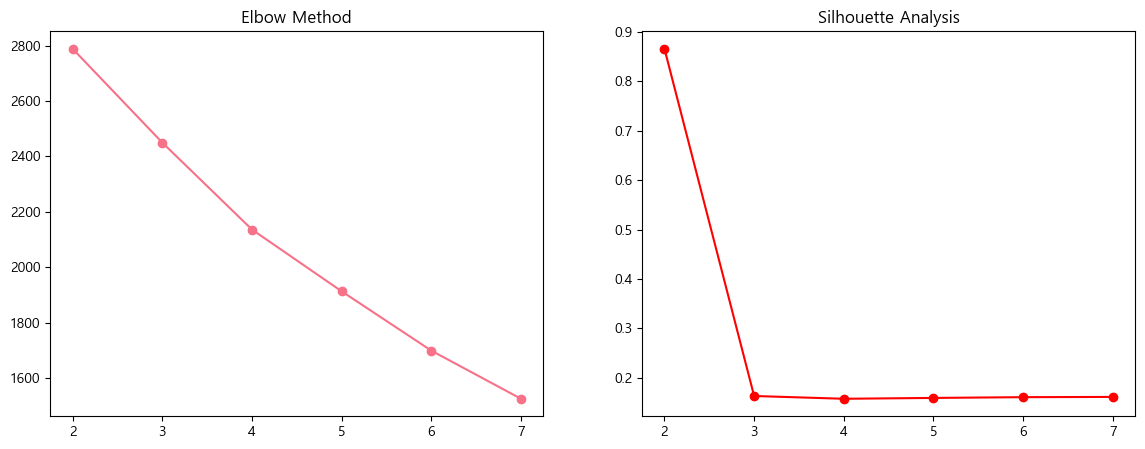

In [55]:
inertias = []
silhouettes = []
K_range = range(2, 8)

X_pca = pca_model.fit_transform(X_scaled)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# 결과 시각화
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[1].plot(K_range, silhouettes, marker='o', color='red')
ax[1].set_title("Silhouette Analysis")
plt.show()

In [66]:
from sklearn.cluster import KMeans

# 1. 전 (Jeon)님 의견대로 최적의 K=2로 군집화 실행
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
df_main['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. 군집별 특징 확인
cluster_summary = df_main.groupby('Cluster')[['LengthOfStay', 'LabTestCount', 'Total_Abnormal_Count']].mean()
print("### K=2 기준 군집별 주요 지표 평균값 ###")
display(cluster_summary)

### K=2 기준 군집별 주요 지표 평균값 ###


,LengthOfStay,LabTestCount,Total_Abnormal_Count
Cluster,,,
0,11.153110,315.526316,40.248804
1,9.791411,279.374233,36.153374


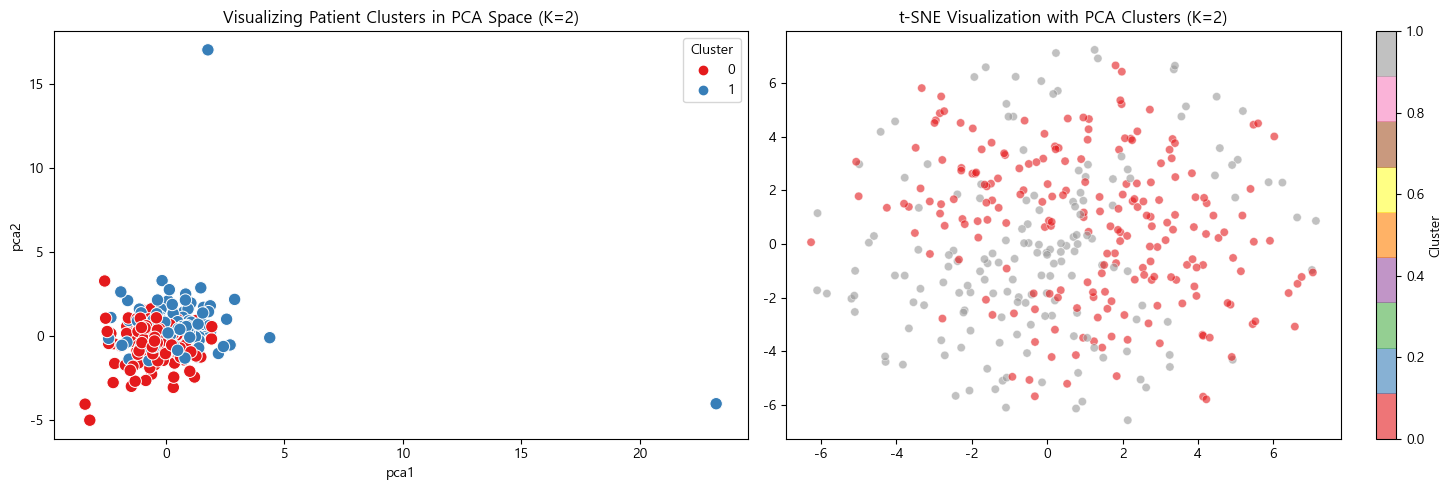

In [70]:
# 1. PCA 변환 결과(X_pca)를 데이터프레임으로 변환
# 위에서 실행한 X_pca = pca_model.fit_transform(X_scaled) 결과를 활용함
df_pca = pd.DataFrame(X_pca[:, :2], columns=['pca1', 'pca2'])
df_pca['Cluster'] = df_main['Cluster'].values  # 인덱스 불일치 방지를 위해 .values 사용

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 2. PCA 공간에서의 군집 시각화
sns.scatterplot(x='pca1', y='pca2', hue='Cluster', data=df_pca, palette='Set1', s=80, ax=ax[0])
ax[0].set_title("Visualizing Patient Clusters in PCA Space (K=2)")

# 3. (추가) t-SNE 결과도 군집 라벨로 시각화 (검증용)
sns.scatterplot(tsne_res[:, 0], tsne_res[:, 1], c=df_main['Cluster'], cmap='Set1', alpha=0.6,legend=False, ax=ax[1])
ax[1].set_title('t-SNE Visualization with PCA Clusters (K=2)')
fig.colorbar(scatter, ax=ax[1], label='Cluster')

plt.tight_layout()
plt.show()

### ⚠️ 군집 분석 한계 및 비판적 해석

**1. 인위적 분리**
PCA 45도 선형 궤적 분리 확인. 
질적 차이 아닌 수치 합계에 따른 단순 절단임.

**2. 식별력 부재**
t-SNE 상 경계 모호 및 데이터 혼재. 
단순 군집화로 복잡 패턴 구분 불가.

**3. 유의성 미비**
시각적 분리에도 불구, 입원 기간 등 핵심 지표 차이 미달.

## 6. 주요 인사이트 요약

### 📌 핵심 발견사항

1. **환자 특성**
   - **분포:** 성비 균형(F 52%, M 48%), 60대 이상 고령층 밀집.
   - **인종:** White(49%) 중심의 다인종 데이터 구성.

2. **입원 패턴**
   - **통계:** 평균 10.6일(중앙값 10일), 우측 편포 구조.
   - **특이사항:** 성별·연령에 따른 입원 기간(LOS) 차이 없음.

3. **검사 및 진단 경향**
   - **상관성:** LOS - LabTestCount 상관계수 **0.993** (결정적 변수).
   - **진단:** 최빈 진단 3회 미만으로 매우 다양함 (단순 분류 불가).

4. **심화 패턴 분석**
   - **PCA:** PC1 설명력 **7.0%** (낮은 정보 집약도, 구조 복잡).
   - **군집화:** k=2 실루엣 점수 통계적 실효성 낮음.

5. **결론**
   - **전략:** 인구통계·군집보다 **실질 임상 피처(Lab)**가 예측의 핵심.
   - **방향:** 고차원 비선형 관계 학습을 위한 트리 기반 모델링 필요.
   
**다음 단계:** 04_modeling.ipynb에서 모델링을 진행합니다.